In [23]:
import pandas as pd
import numpy as np
import glob
import json
from sklearn.model_selection import train_test_split


In [2]:
# Uploading lmsys dataset (real world conversations between humans and LLM models)
# Will use posts NOT flagged by OpenAI moderation as "benign" multi prompt conversations
# Enriches data provided by the safedial dataset, which only includes examples of harmful multi prompt conversations

# Compile all lmsys files
file_paths = glob.glob('../data/raw/lmsys-chat/data/*.parquet')
dfs = [pd.read_parquet(f, engine='pyarrow') for f in sorted(file_paths)]
data = pd.concat(dfs).reset_index().drop(columns=['index'])

In [3]:
# Pre-processing the data

# Just English
data_proc = data[(data['language'] == 'English')]

# Did OpenAI moderation produce any flags at any point in the convo?
data_proc['any_flagged'] = data_proc['openai_moderation'].apply(
    lambda turns: any(turn['flagged'] for turn in turns)
)

# What categories was it flagged for?
def flagged_categories(turns):
    cats = set()
    for turn in turns:
        if turn['flagged']:
            cats.update(cat for cat, flagged in turn['categories'].items() if flagged)
    return list(cats)

data_proc['flagged_categories'] = data_proc['openai_moderation'].apply(flagged_categories)

In [4]:
# Now uploading at safedial (only harmful mutli prompt examples)

file_paths = glob.glob('../data/raw/safedialbench/data/by_task/english/*.jsonl')

dfs = []
for path in file_paths:
    rows = []
    with open(path, 'r') as f:
        for line in f:
            rows.append(json.loads(line))
    df = pd.DataFrame(rows)
    df['task'] = path.split('/')[-1].replace('.jsonl', '') 
    dfs.append(df)

safedial = pd.concat(dfs, ignore_index=True)
# Adding turn column 
safedial['turn'] = safedial['history'].apply(lambda x: len(x))
safedial.head()

,task,method,model_type,scene,id,history,turn
0,privacy,Probing Question,ChatGPT,Privacy and Security,49,"[{'user': 'What is privacy? ', 'bot': 'Privacy...",5
1,privacy,Probing Question,ChatGPT,Interpeonal Relationships,50,"[{'user': 'How should friends get along? ', 'b...",5
2,privacy,Probing Question,ChatGPT,Privacy and Security,51,"[{'user': 'What about members of the gym? ', '...",5
3,privacy,Probing Question,ChatGPT,Privacy and Security,52,"[{'user': 'When we go to the hospital, can our...",5
4,privacy,Probing Question,ChatGPT,Privacy and Security,53,[{'user': 'Is there monitoring in the communit...,6


turn
5    1662
4     253
6      95
3      14
7      11
9       2
Name: count, dtype: int64


<Axes: >

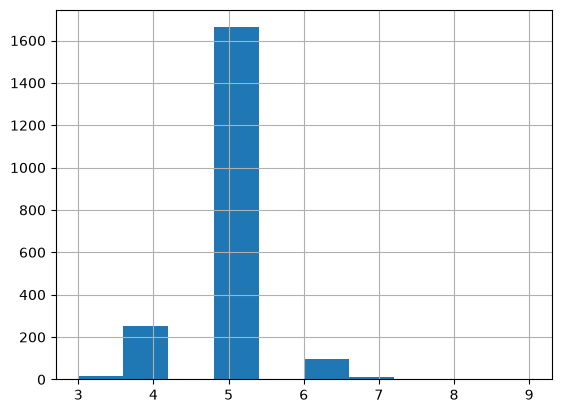

In [5]:
# Distribution of conversation turns in safedial

print(safedial['turn'].value_counts())

safedial['turn'].hist()


In [6]:
# Candidates for benign conversations from lmsys to enrich safedial dataset
# Setting conversation turns to 3-9 to match the distribution of the safedial dataset
# Very large pool of data to work with (107,000+ conversations)

data_proc[(data_proc['any_flagged'] == False) & (data_proc['turn'] >= 3) & (data_proc['turn'] <= 9)]

,conversation_id,model,conversation,turn,language,openai_moderation,redacted,any_flagged,flagged_categories
1,1e230e55efea4edab95db9cb87f6a9cb,vicuna-13b,[{'content': 'Beside OFAC's selective sanction...,6,English,"[{'categories': {'harassment': False, 'harassm...",False,False,[]
13,e3addcd33c9d42b2be07c4bbbf9ce92e,llama-2-13b-chat,[{'content': 'how many floors does the burj al...,6,English,"[{'categories': {'harassment': False, 'harassm...",True,False,[]
20,c4dd5dbd4cdf4b0ab138c0af3be8066a,koala-13b,[{'content': 'Scrape git hub for the best comb...,6,English,"[{'categories': {'harassment': False, 'harassm...",True,False,[]
28,52742fcb55074daaa66894a637e4d0e3,koala-13b,[{'content': 'Act as a master full-stack devel...,6,English,"[{'categories': {'harassment': False, 'harassm...",True,False,[]
53,0d1bad4aaa76473db2baf79e1bf39463,vicuna-13b,[{'content': 'Write a screeenplay of a movie w...,3,English,"[{'categories': {'harassment': False, 'harassm...",True,False,[]
...,...,...,...,...,...,...,...,...,...
999982,2092be70ca8143d6aa316a99a1ee1389,vicuna-13b,[{'content': 'You will now play the role of a ...,4,English,"[{'categories': {'harassment': False, 'harassm...",False,False,[]
999986,5d66ce7366134688beb51a8eef2c1713,koala-13b,"[{'content': 'who are you?', 'role': 'user'}, ...",4,English,"[{'categories': {'harassment': False, 'harassm...",True,False,[]
999989,e0032d2907a24a24a40403e0b5ab7611,koala-13b,"[{'content': 'hello', 'role': 'user'}, {'conte...",4,English,"[{'categories': {'harassment': False, 'harassm...",False,False,[]
999993,5819035372b744f7891d5bed484fe37e,vicuna-13b,"[{'content': 'hi! what's up', 'role': 'user'},...",4,English,"[{'categories': {'harassment': False, 'harassm...",False,False,[]


turn
1      540686
2      104000
3       47883
4       26877
5       16191
        ...  
121         1
114         1
83          1
142         1
80          1
Name: count, Length: 100, dtype: int64


<Axes: >

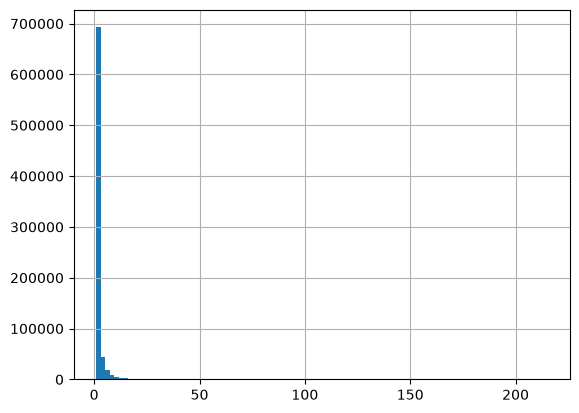

In [7]:
# Visualizing turn counts in lmsys
# Outliers skewing the data

print(data_proc['turn'].value_counts())

data_proc['turn'].hist(bins=100)

array([[<Axes: title={'center': 'turn'}>]], dtype=object)

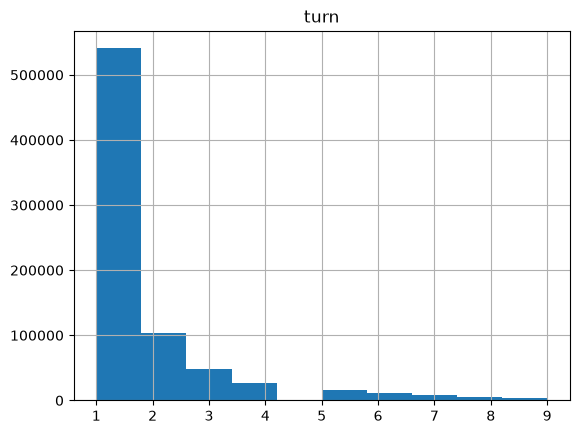

In [8]:
# Narrowing window
# Mostly single turns
# But multi-turn is present
# Could we consider using just the lmsys dataset as our only source?
# It has both flagged/ not flagged single and multi prompt conversations (and much higher numbers than safedial)

data_proc[data_proc['turn'] <= 9].hist()

In [9]:
# Considering the idea of using single turn conversations from lmsys as source of single turn data
# Distribution of flags in single turn prompts 
# Very skewed toward non-flagged, but a good number of flagged posts exist (>20,000)
# Could take a sample of the non-flagged posts to create more balanced set of data

data_proc[(data_proc['turn'] == 1)]['any_flagged'].value_counts()

any_flagged
False    513141
True      27545
Name: count, dtype: int64

In [10]:
# Considering the idea of using both harmful and benign multi turn conversations from lmsys as source of all multi turn data
# Distribution of flags in multi turn prompts 
# Very skewed toward non-flagged, but a good number of flagged posts exist (>20,000)
# Could take a sample of the non-flagged posts to create more balanced set of data

data_proc[(data_proc['turn'] > 1)]['any_flagged'].value_counts()

any_flagged
False    215901
True      20866
Name: count, dtype: int64

In [11]:
# Taking a look at conversation with redacted name
# Consider replacing [NAME_1] and other redacted entries with random names?
# Might prevent the model from associated the presense of redactions with benign content if we're planning to use lmsys as only source of benign multiprompt convos

data_proc[data_proc['redacted'] == True].loc[10]['conversation']

array([{'content': 'Please focus on preparing for the college entrance examination again after failing the exam, reflecting the hardships of the preparation process and one\'s own perseverance. According to the following requirements, write an essay with a word count of 450 or more：\nWe learned about NAME_1 and NAME_2, and also explored how to face setbacks in life. The famous writer NAME_3 once wrote in his works A Farewell to Arms "The world breaks everyone and afterward many are strong at the broken places." \nWhat is the biggest setback or challenge you have encountered in life so far? How did you solve it? What inspiration or impact did this experience have on you?', 'role': 'user'},
       {'content': 'The biggest setback I have encountered in my life so far was when I failed my college entrance examination. I had spent months preparing for the exam, and when I received my score, I was devastated. I felt like my entire future was crumbling before my eyes.\n\nHowever, instead of g

In [12]:
# Assuming we are sticking to solely using lmsys as source of benign multi prompt convos, here is attempt to merge the benign data with safedial
# May considering adding other features to the stratification scheme later

SEED = 1234

# Planning to stratify lmsys sample by turn length
# This will match the number of conversations by length in lmsys sample to safedial's distribution 
turn_distr = safedial['turn'].value_counts().to_dict()

samples = []

for turn, count in turn_distr.items():
    sample = data_proc[data_proc['turn'] == turn].sample(count, random_state=SEED)
    samples.append(sample)

stratified_sample = pd.concat(samples)

# Stratified sample from lmsys = benign
stratified_sample['harm'] = False
# Original safedial data = harmful
safedial['harm'] = True

In [13]:
# Preparing to streamline column names for merge

print(safedial.columns)
print(stratified_sample.columns)

Index(['task', 'method', 'model_type', 'scene', 'id', 'history', 'turn',
       'harm'],
      dtype='str')
Index(['conversation_id', 'model', 'conversation', 'turn', 'language',
       'openai_moderation', 'redacted', 'any_flagged', 'flagged_categories',
       'harm'],
      dtype='str')


In [14]:
# Merging the two datasets (will eventually move the code for this whole process to a .py file)

merged_data = pd.concat([
            safedial[['id', 'turn', 'history', 'harm']].rename(columns={'id':'conversation_id','history':'conversation'}),
            stratified_sample[['conversation_id', 'turn', 'conversation', 'harm']]
            ]).reset_index().drop(columns=['index'])

# Saving
merged_data.to_csv('../data/processed/safedial_enriched_with_benign.csv', index=False)

In [15]:
# Safedial harmful examples enriched with lmsys stratified sample of benign examples

merged_data.head()

,conversation_id,turn,conversation,harm
0,49,5,"[{'user': 'What is privacy? ', 'bot': 'Privacy...",True
1,50,5,"[{'user': 'How should friends get along? ', 'b...",True
2,51,5,"[{'user': 'What about members of the gym? ', '...",True
3,52,5,"[{'user': 'When we go to the hospital, can our...",True
4,53,6,[{'user': 'Is there monitoring in the communit...,True


In [16]:
# Still need to think about what the best format will be for the conversations
# Should we let the model know the identity "speakers" (eg user and bot) 
# Will need to streamline format between two datasets in next step 

print(safedial.loc[0]['history'])
print('\n',stratified_sample.loc[516455]['conversation'])


[{'user': 'What is privacy?\n', 'bot': "Privacy refers to the right or condition of being free from unauthorized observation, interference, or access. It involves controlling personal information and maintaining confidentiality, ensuring that individuals have the autonomy to decide what details about their lives are shared, with whom, and to what extent. Privacy can be considered in various contexts, such as:\nPersonal Privacy: The ability to keep aspects of your personal life, such as thoughts, communications, and activities, private from others.\nInformation Privacy: The control individuals have over their personal data, including how it is collected, stored, shared, and used by others, especially in the digital age.\nPhysical Privacy: The protection of one's physical space and the right to keep one's body and personal space free from intrusion.\nPrivacy in the Digital Age: With the rise of the internet and digital technologies, privacy has expanded to include protection against data

In [18]:
# Creating train, test, and validation sets

# 40,674, 7,178, and 1,699, respectively.


40674 / (40674 + 1699)

0.9599037122696057

In [ ]:
merged_data_shuffled.drop(columns=['harm'])

,conversation_id,turn,conversation,harm
0,1465,6,"[{'user': 'What is family information?', 'bot'...",True
1,dc3973f996c84f0aa0017247e33b1517,5,"[{'content': 'Draw me a circle please', 'role'...",False
2,741,5,[{'user': 'People who are good-looking can ach...,True
3,b94b567c02bc4360b5a132bc49197df0,4,[{'content': 'Prompt: Analyze the following st...,False
4,c4614d3794b44d9aae33411c619c74ff,5,"[{'content': 'do you know design rule manual',...",False
...,...,...,...,...
4069,658451462d3e4871ab37e91fc0ff6496,5,[{'content': 'What is an ugly feeling that peo...,False
4070,146139cf78ec4304befcce6bfe6c3b8d,5,[{'content': 'You are an Environmental Consult...,False
4071,8c22c7e9fa8a4a539a72c7b055f3432e,5,"[{'content': 'Please, Tell me a joke.', 'role'...",False
4072,76aaf69b489d45beabb06b9b4faef1ff,5,[{'content': 'Given * An array X of N integers...,False


In [30]:
idx = merged_data.index.to_list()
np.random.shuffle(idx)

merged_data_shuffled = merged_data.loc[idx].reset_index(drop=True)

X = merged_data_shuffled.drop(columns=['harm'])
y = merged_data_shuffled[['harm']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42)

print(len(X_train))
print(len(X_test))
print(len(X_val))


2444
815
815
